# **SIT307 – Task 11.1HD: Machine Learning Mini Research** 

# **Name:** Huynh Quang Vinh (Kent)

# **Student ID:** 224672479

# **Email:** s224672479@deakin.edu.au  

# **Unit:** SIT307 – Machine Learning 

# Part 1: Understanding and Reproducing Published Machine Learning Results

In [1]:
!pip install xgboost

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1. Dataset Preproduction

In this task, I will select the third research paper, which is an efficient stacking-based ensemble technique for early heart attack prediction. I will reproduces the same machine learning methodology with the research paper, then evaluating an improved machine learning solution. 

The reproduction will follow the main experimental methodology described in the selected paper.

| Component | Published Paper |
|---|---|
| Dataset | Public Heart Disease Dataset |
| Number of records | 1025 |
| Number of attributes | 14 including the target |
| Target | Heart disease: 0 = no disease, 1 = disease |
| Preprocessing | Missing value handling, scaling, and categorical encoding |
| Individual models | Logistic Regression, Decision Tree, Random Forest, XGBoost, Naive Bayes, K-Nearest Neighbors |
| Ensemble method | Stacking |
| Stacking validation | 5-fold |
| Evaluation | Accuracy, Precision, Recall, F1 Score, AUC |

At first, I will download the Hear Disease dataset from the provided link in the research paper. Then, the dataset will be loaded and checked to ensure that its structure and features are similar with the research paper. 

In [3]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

According to the result, the dataset contains 1025 records and 14 attributes, which is similar with the dataset description in the research paper. 

Then, I will check all the columns names to ensure that the same attributes described in the published paper. 

In [5]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

The result shows that dataset contains 13 features and 1 target variable, which is similar with the research paper result. 

Then, I will start to check the info of this dataset to acknowledge general data types and missing values. 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

According to the result, the dataset used in the research paper contain 0 missing value, although the paper demonstrates missing-value handling as part of preprocessing pipeline. 

Then, I will check the duplocate records in the dataset. 


In [8]:
df.duplicated().sum()

723

Finally, the target distribution will be evaluate. In the target variable, 0 represents for no heart disease and 1 represents for heart disease. 

In [9]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [10]:
df["target"].value_counts(normalize=True) * 100

target
1    51.317073
0    48.682927
Name: proportion, dtype: float64

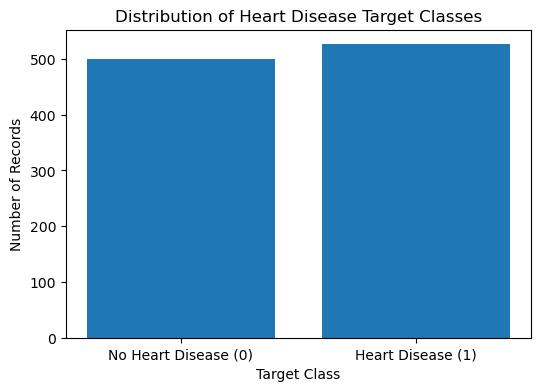

In [11]:
target_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No Heart Disease (0)", "Heart Disease (1)"], target_counts.values)
plt.xlabel("Target Class")
plt.ylabel("Number of Records")
plt.title("Distribution of Heart Disease Target Classes")
plt.show()

According to all the results, the dataset contains 1025 records and 14 attributes, which is similar with the dataset in the research paper. Moreover, there are no any missing value in the dataset although the search paper includes the missing-value handling as a part of preprocessing pipeline. The target variable is quite balanced with 526 positive cases and 499 negative cases. However, this dataset contains 723 duplicated rows, which will be retained for the reproduction study because the research paper using all 1025 records and does not declare that duplicate rows is removed. 

The research paper also includes the scaling method in preprocessing step. Therefore, I will start to check the features ranges to check whether it is necessary for scaling. 

In [12]:
df.describe().loc[["min", "max"]]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
min,29.0,0.0,0.0,94.0,126.0,0.0,0.0,71.0,0.0,0.0,0.0,0.0,0.0,0.0
max,77.0,1.0,3.0,200.0,564.0,1.0,2.0,202.0,1.0,6.2,2.0,4.0,3.0,1.0


In [13]:
categorical_features = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

for column in categorical_features:
    print(column, sorted(df[column].unique()))

sex [0, 1]
cp [0, 1, 2, 3]
fbs [0, 1]
restecg [0, 1, 2]
exang [0, 1]
slope [0, 1, 2]
ca [0, 1, 2, 3, 4]
thal [0, 1, 2, 3]


According to the result, most feature ranges are similar with the attribute description reported in the research paper. However, 2 discrepancies are observed, which are ca = 4. Because the paper reports a range of 0-3. Then, the thal is also considered because the report demonstrate that thal have a values from 1 - 3. All categorical features are already represented numerically in the provided dataset. Therefore, no additional categorical encoding is required at this stage. The original values are retained for the reproduction study because the paper reports using the full dataset of 1025 records.

### 2. Data Preprocessing

The research paper demonstrate the preprocessing that it includes missing-value handling, categorical encoding and feature scaling. In the provided dataset, no missing value are present and al categorical features are already numerical encoded. Therefore, no additional imputation or encoding is applied. Moreover, the research paper does not demonstrate specific the exact scaling method or random seed used in the train-test slpit. Therefore, I will apply the Standard Scaler and fixed random state will be used. 

In [14]:
X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1025, 13)
y shape: (1025,)


Then, I will split the dataset into the 80:20 ratio although the research paper does not state the train split ratio. However, the reported confusion matrix for stacking model contains 205 test samples. Because full dataset contains 1025 records, which means that around 20% of the dataset. 

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 820
Testing samples: 205


Then, I will apply the feature scaling after spliting dataset into training and testing sets. Then, the scaler is fitted only on the training data and applied to both training and testing data to avoid using information from the test set during preprocessing. 

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(820, 13)
(205, 13)


## 3. Reproduction of Individual Classifier 

### Logistic Regression

The first classifier is Logistic Regression, which is reproduced from the research paper. However, the publish paper does not report the exact Logistic Regression hyperparameter settings. Therefore, the default Logistic Regression model from scitkit-learn implementation will be used. The model is trained by using the scaled training data and evaluated on the held out dataset. According to scikit-learn (2014), the default setting of Logistic Regression includes the lbfgs solver, regularisation strength C = 1.0, L2 regularisation, tolerance 0.0001, intercept fitting enabled, no class weighting, and a maximum of 100 iterations.

In [18]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

LogisticRegression()

Then, I will use the trained model to predict the target class. Then, probabilities are also stored to calculate the AUC and ROC curve in some next steps. 

In [19]:
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

After that, the Logistic Regression model is evaluated by using Accuracy, Precision, Recall, F1 Score and AUC, which are similar with the evaluation metrics in the research paper. 

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("AUC      :", lr_auc)

Accuracy : 0.7951219512195122
Precision: 0.7563025210084033
Recall   : 0.8737864077669902
F1 Score : 0.8108108108108109
AUC      : 0.8787359604035789


According to the result, the reproduced Logistic Regression model can achieve an accuracy at 79.51%, which is lower than the score in the research paper at 84.39%. Then, precision, recall, f1 score and AUC is also lower than the result in research paper. The difference may be influnced by implementation details that are not fully specified in the paper, which includes the exact train test split, random seed, scaling and Logistic Regression hyperparameters. In this reproduction, a fixed random state of 42, StandardScaler and the default scikit-learn Logistic Regression configuration is applied as reproducible assumptions. 

Then, I will also use the confusion matrix to evaluate the number of correctly and incorrectly classified heart disease case. 

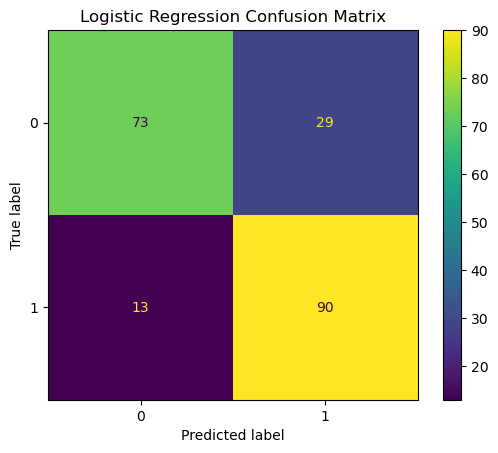

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

According to result, the Logistic Regression model correctly classified 90 heart disease acses and 73 normal cases. However, 29 negative cases is incorrectly predicted as positive, while 13 positive cases is missed. The relatively small number of false negatives is consistent with the model's higher recall of 87.38%. However, the larger number of false positives reduces precision to 75.63%.

Finally, the ROC curve is visualized by using the predicted probabilities to evaluate the model ability to distinguish between 2 target class across different classification thresholds. 

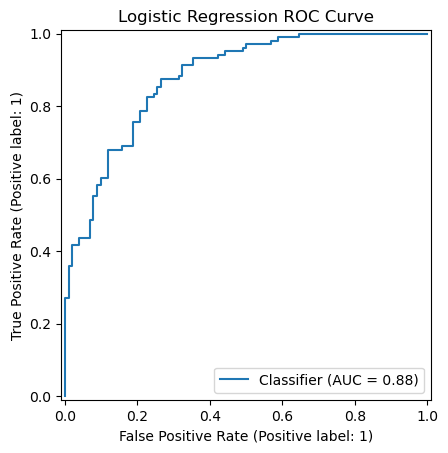

In [22]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    lr_prob
)

plt.title("Logistic Regression ROC Curve")
plt.show()

The ROC curve demonstrate that reproduced Logistic Regression model has a good ability to distinguish 2 target classes with an AUC score at around 0.88. However, this is lower than research paper result, which have around 0.92 AUC score, which means that the reproduced model provides weaker class separation than the result in the research paper. 

### Decision Tree

Then, the Dicision Tree model is reproduced depending on the algorithm in the research paper, which procudure calculates entropy when selecting attributes for node splitting. Therefore, the entropy criterion is used in this reproduction. The papaer does not report other Decision Tree hyperparameters. Therefore, these setting will be set as default of scikit-learn. The fixed random state is also used to make the result consistent across repeated runs. According to scikit-learn (2019), the default settings of Decision Tree includes splitter="best", max_depth=None, min_samples_split=2, min_samples_leaf=1 and max_features=None.

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

Then, the trained Decision Tree model is used to predict the test classes. The class probabilities is also stored to calculate the AUC score later. 

In [24]:
dt_pred = dt_model.predict(X_test_scaled)
dt_prob = dt_model.predict_proba(X_test_scaled)[:, 1]

Then, I will use some evaluation matrics similar with the research paper.

In [25]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_prob)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("AUC      :", dt_auc)

Accuracy : 0.9853658536585366
Precision: 1.0
Recall   : 0.970873786407767
F1 Score : 0.9852216748768473
AUC      : 0.9854368932038835


According to the result, the reproduced Decision Tree can achieve an accuracy at 98.54%, which is higher than the 92.68% accuracy score in the research paper. Then, precision, recall, f1 score and AUC score is also higher than the research paper. The different may be affected by the hyparparameter setting, which is not included in the research paper. Moreover, the dataset contains a large number of duplicate records. Because theses records is retained to reproduce the full 1025 record dataset in the research paper. 

Then, the confusion matrix is also generate to evaluate the correct and incorrect classification. 

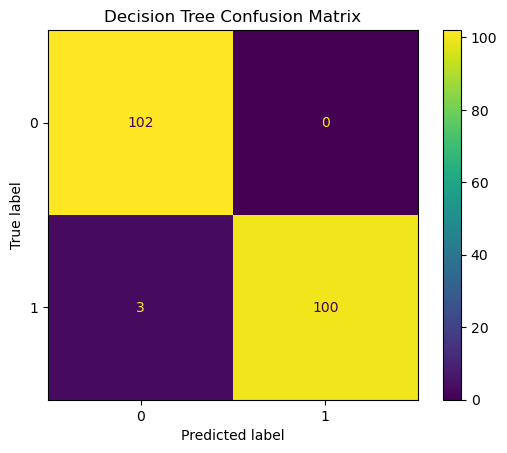

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

The confusion matrix demonstrate 102 true negatives and 100 true positives with no any negative case is incorrectly classified as positive. This is also demonstrated with the Precision at 1. Then, it have only 3 positive cases is missclassfied. 

Finally, the ROC curve is generated to evaluate how well the Decision Tree distinguish. 

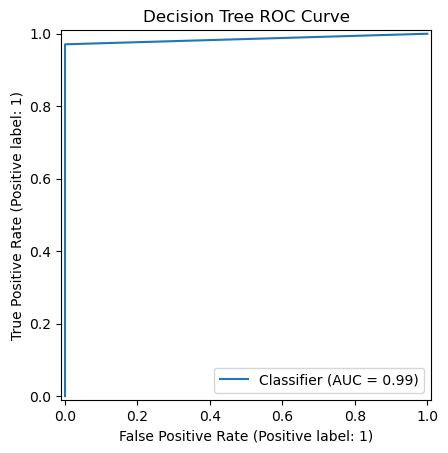

In [27]:
RocCurveDisplay.from_predictions(
    y_test,
    dt_prob
)

plt.title("Decision Tree ROC Curve")
plt.show()

The Decision Tree ROC curve shows excellent discrimination between the two target classes, with an AUC of approximately 0.9854. This is slightly higher than the published AUC of 0.9702. The strong ROC performance is consistent with the near-perfect confusion matrix obtained in the reproduction.

### Random Forest

The Random Forest Classifier model is reproduced similar with the research paper. In the research paper, it demonstrates the Random Forest as an ensemble of Decision Tree by using random subsets and boostrap sampling. However, the research paper is not included the exact hyperparameter settings. Therefore, the scikit-learn default Random Forest is used. According to Scikit-Learn (2025), the default setting of Random Forest Classifier includesn_estimators=100, criterion="gini", max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features="sqrt", and bootstrap=True.

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

Then, I also use the trained Random Forest Classifier to predict and store the probabilities for evaluate the AUC score. 

In [29]:
rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

Then, the same evaluation metrics as above models is used to evaluate and compare the reproduced model with result in the research paper. 

In [30]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("AUC      :", rf_auc)

Accuracy : 0.9853658536585366
Precision: 1.0
Recall   : 0.970873786407767
F1 Score : 0.9852216748768473
AUC      : 1.0


According to the result, the reproduced Random Forest can achieve an accuracy score at 98.54%, which is higher than the 92.68% in the research paper. Then, precision, recall, f1 score and AUC score are higher than the reseach paper. 

Then, I will also generate the confusion matrix to identify the correct and incorrect predictions. 

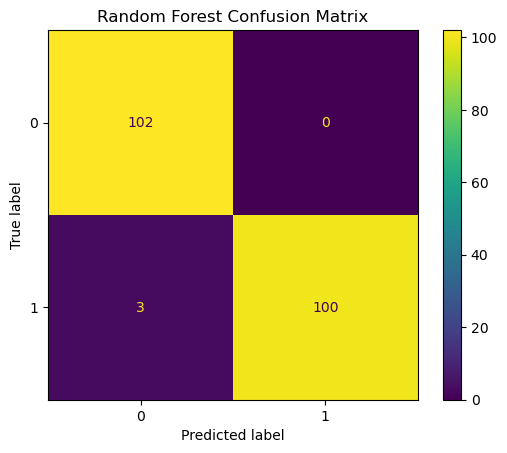

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest Confusion Matrix")
plt.show()

According to the confusion matrix, it shows 102 true negatives and 100 true positive. There are no false positives, while 3 positive cases are misclassified as negative., which is also demonstrated by a recall at 0.97.

Then, the ROC curve is also generated by using the predicted probabilities to evaluate the ability of the Random Forest Classifier to distinguish between 2 target classes. 

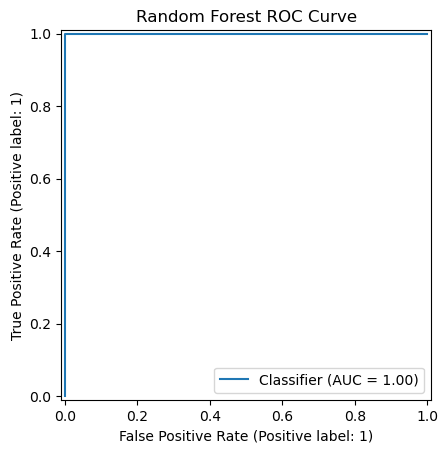

In [32]:
RocCurveDisplay.from_predictions(
    y_test,
    rf_prob
)

plt.title("Random Forest ROC Curve")
plt.show()

The ROC curve of reproduced Random Forest can achieve an AUC score at 1, which demonstrates the perfect class separation on the current test set. This is higher than the AUC score in research paper.

### XGBoost

According to GeeksforGeeks (2021), XGBoost is an optimized gradient boosting algorithm that builds decision trees sequentially. Each new tree attempts to correct errors from the previous trees, while regularization helps control model complexity and reduce overfitting. In this reproduction, XGBoost is used as one of the six classifiers evaluated in the published study. However, the research paper does not include the exact hyperparameter setting, so the default XGBoost classifier will be used. 

In [33]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

Then, the trained XGBoost model is used to predict and store the predicted probabilities for calculating AUC score later. 

In [34]:
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

After that, some same evaluate metrics is used to compare with the result in the research paper. 

In [35]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("AUC      :", xgb_auc)

Accuracy : 0.9853658536585366
Precision: 1.0
Recall   : 0.970873786407767
F1 Score : 0.9852216748768473
AUC      : 0.9894346087949742


According to the result, the reproduced XGBoost model can achieve an accuracy score at 98.54%, which is higher than the 90.73% in the research report. Then. precision, recall, f1 score and AUC score is also higher than the research paper result. 

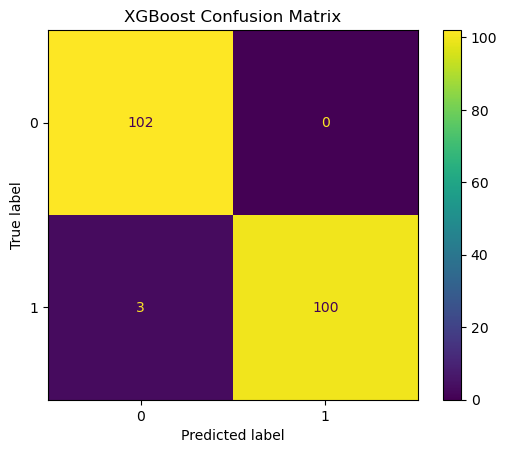

In [36]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred
)

plt.title("XGBoost Confusion Matrix")
plt.show()

The confusion matrix demonstrates 102 true negative and 100 true positives with no any case is missclassified as positive, which is represented by the precision at 1. Then, only 3 positives cases is incorrecly predicted as negative. 

After that, the ROC curve is also visualized by using the predicted probabilities to evaluate the ability of the XGBoost to distinguish between 2 target classes. 

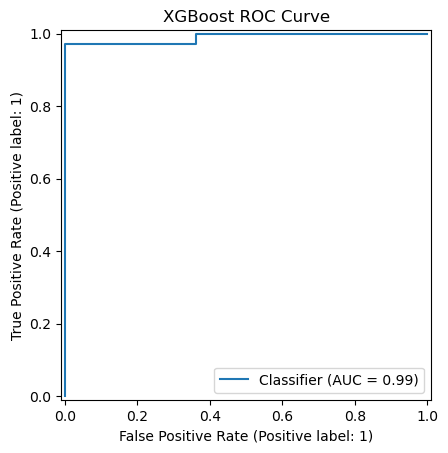

In [37]:
RocCurveDisplay.from_predictions(
    y_test,
    xgb_prob
)

plt.title("XGBoost ROC Curve")
plt.show()

The ROC curve of the reproduced model can achieve an AUC score at around 0.99, which demonstrating a very good distinguish between 2 classes. This is also higher than the AUC score in the research paper, which is around 0.9830. 

### Naive Bayes

Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem. It assumes that the input features are conditionally independent given the target class. The model estimates the probability of each class from the observed features and assigns the class with the highest posterior probability (GeeksforGeeks, 2017). However, the research paper does not specify which Naive Bayes variant is used, so Gaussian Naive Bayes is used as a reasonable implementation assumption because the dataset contains numerical clinical measurements such as age, bllod pressure, cholesterol, maximum hear rate and ST depression. According to Scikit-learn (2019), the default settings include priors=None, where class prior probabilities are estimated from the training data, and var_smoothing=1e-9, which adds a small amount of variance for numerical stability.

In [38]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

Then, the trained Naive Bayes model is used to predict and store the predicted probabilities for calculating AUC score later. 

In [39]:
nb_pred = nb_model.predict(X_test_scaled)
nb_prob = nb_model.predict_proba(X_test_scaled)[:, 1]

After that, some same evaluate metrics is used to compare with the result in the research paper. 

In [40]:
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)
nb_auc = roc_auc_score(y_test, nb_prob)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)
print("AUC      :", nb_auc)

Accuracy : 0.8
Precision: 0.7540983606557377
Recall   : 0.8932038834951457
F1 Score : 0.8177777777777778
AUC      : 0.8705501618122977


According to the result, the reproduced Gaussian Naive Bayes model achieves an accuracy of 80.00%, compared with 84.39% reported in the published study. Its recall of 89.32% is close to the published value of 90.00%, while precision, F1 Score, and AUC is lower.

Then, the confusion matrix is examined to identify the correct and incorrect predictions produced by the reproduced Naive Bayes classifier.

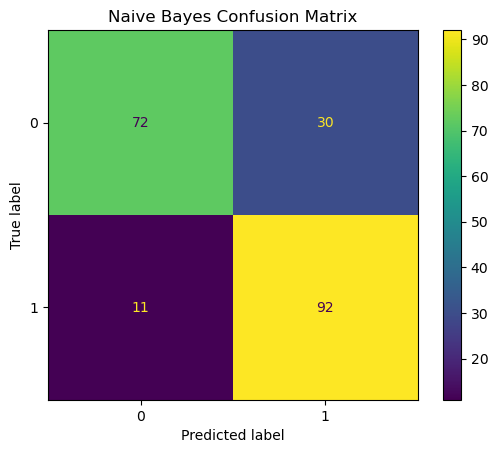

In [41]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_pred
)

plt.title("Naive Bayes Confusion Matrix")
plt.show()

The confusion matrix shows 72 true negatives and 92 true postives. This means that the model can incorrectly classify 30 negative cases as positive and miss 11 positive cases. 

After that, the ROC curve is also visualized by using the predicted probabilities to evaluate the ability of the Naive Bayes to distinguish between 2 target classes. 

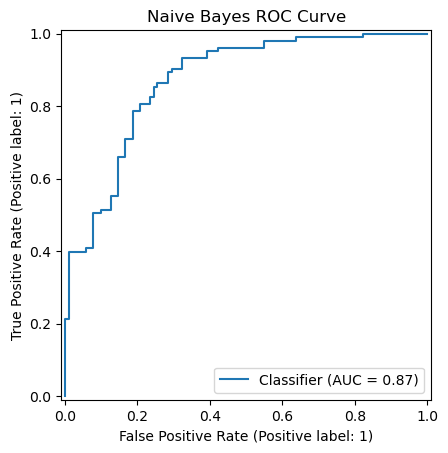

In [42]:
RocCurveDisplay.from_predictions(
    y_test,
    nb_prob
)

plt.title("Naive Bayes ROC Curve")
plt.show()

The ROC cureve can achieve the AUC score at around 0.87, which demonstrating a good ability to distinguish between 2 classes. However, this is lower than the result in the research paper, which have an AUC score around 0.9185. 

### KNN

According to Bhagat et al. (2024), K-Nearest Neighbors (KNN) is a non-parametric classification algorithm that predicts the class of a new observation based on the classes of its nearest training samples. The most common class among the selected neighbours is assigned as the final prediction. KNN is sensitive to feature scales and the choice of number of neighbor, so the scaled dataset is used in this reproduction. However, the research paper does not report the exact KNN parameter settings. Therefore, the default scikit-learn configuration is used as a reproducible assumption, which includes n_neighbors=5, weights="uniform", algorithm="auto", leaf_size=30, metric="minkowski", and p=2. With p=2, the Minkowski distance corresponds to Euclidean distance (scikit-learn, 2019a). 

In [43]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

Then, the trained KNN model is used to predict and store the predicted probabilities for calculating AUC score later. 

In [44]:
knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

After that, some same evaluate metrics is used to compare with the result in the research paper. 

In [45]:
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
knn_auc = roc_auc_score(y_test, knn_prob)

print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)
print("AUC      :", knn_auc)

Accuracy : 0.8341463414634146
Precision: 0.8
Recall   : 0.8932038834951457
F1 Score : 0.8440366972477065
AUC      : 0.9485532076908434


The reproduced KNN model can achieve an accuracy at 83.41%, which is slightly lower than the 85.85% reported in the published study. Precision and F1 Score are also lower, while recall and AUC can reach 89.32% and 0.9486, respectively, which is higher than the result in research paper. This means that the reproduced KNN model can classify positive heart disease cases better, but it includes more false positive predictions than the research paper result.

Then, the confusion matrix is examined to identify the correct and incorrect predictions produced by the reproduced KNN classifier.

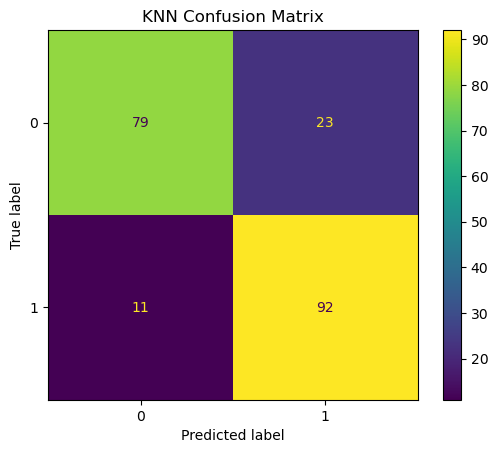

In [46]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred
)

plt.title("KNN Confusion Matrix")
plt.show()

The confusion matrix demonstrates  79 true negatives and 92 true positives with incorrectly classify 23 negative cases as positive and miss 11 positive cases.

After that, the ROC curve is also visualized by using the predicted probabilities to evaluate the ability of the KNN to distinguish between 2 target classes. 

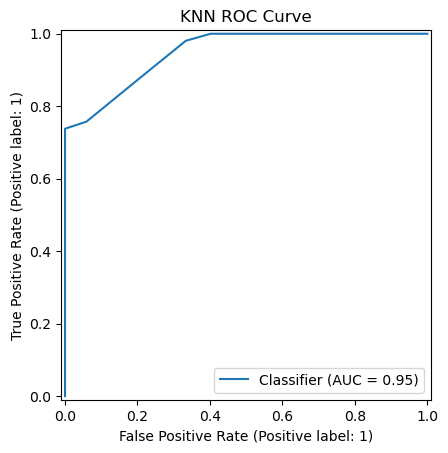

In [47]:
RocCurveDisplay.from_predictions(
    y_test,
    knn_prob
)

plt.title("KNN ROC Curve")
plt.show()

The ROC curve can achieve an AUC score at around 95%, which is higher than the research paper AUC score wit 0.9304. This means that the reproduced KNN model has a strong ability to distinguish between 2 classes. 

Finally, I will create the result table of 6 individual classifiers and compare with the results in the research paper. 

In [48]:
published_results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest",
              "XGBoost", "Naive Bayes", "KNN"],
    "Research Paper Accuracy": [0.8439, 0.9268, 0.9268, 0.9073, 0.8439, 0.8585],
    "Research Paper Precision": [0.8196, 0.9702, 0.9130, 0.9174, 0.8250, 0.8648],
    "Research Paper Recall": [0.9090, 0.8909, 0.9545, 0.9090, 0.9000, 0.8727],
    "Research Paper F1": [0.8620, 0.9289, 0.9333, 0.9132, 0.8608, 0.8687],
    "Research Paper AUC": [0.9204, 0.9702, 0.9734, 0.9830, 0.9185, 0.9304]
}

reproduced_results = {
    "Reproduced Accuracy": [
        lr_accuracy, dt_accuracy, rf_accuracy,
        xgb_accuracy, nb_accuracy, knn_accuracy
    ],
    "Reproduced Precision": [
        lr_precision, dt_precision, rf_precision,
        xgb_precision, nb_precision, knn_precision
    ],
    "Reproduced Recall": [
        lr_recall, dt_recall, rf_recall,
        xgb_recall, nb_recall, knn_recall
    ],
    "Reproduced F1": [
        lr_f1, dt_f1, rf_f1,
        xgb_f1, nb_f1, knn_f1
    ],
    "Reproduced AUC": [
        lr_auc, dt_auc, rf_auc,
        xgb_auc, nb_auc, knn_auc
    ]
}

comparison_df = pd.DataFrame(published_results)

for column, values in reproduced_results.items():
    comparison_df[column] = values

comparison_df.round(4)

,Model,Research Paper Accuracy,Research Paper Precision,Research Paper Recall,Research Paper F1,Research Paper AUC,Reproduced Accuracy,Reproduced Precision,Reproduced Recall,Reproduced F1,Reproduced AUC
0,Logistic Regression,0.8439,0.8196,0.9090,0.8620,0.9204,0.7951,0.7563,0.8738,0.8108,0.8787
1,Decision Tree,0.9268,0.9702,0.8909,0.9289,0.9702,0.9854,1.0000,0.9709,0.9852,0.9854
2,Random Forest,0.9268,0.9130,0.9545,0.9333,0.9734,0.9854,1.0000,0.9709,0.9852,1.0000
3,XGBoost,0.9073,0.9174,0.9090,0.9132,0.9830,0.9854,1.0000,0.9709,0.9852,0.9894
4,Naive Bayes,0.8439,0.8250,0.9000,0.8608,0.9185,0.8000,0.7541,0.8932,0.8178,0.8706
5,KNN,0.8585,0.8648,0.8727,0.8687,0.9304,0.8341,0.8000,0.8932,0.8440,0.9486


I will generate a graph to display the accuracy score of 2 results. 

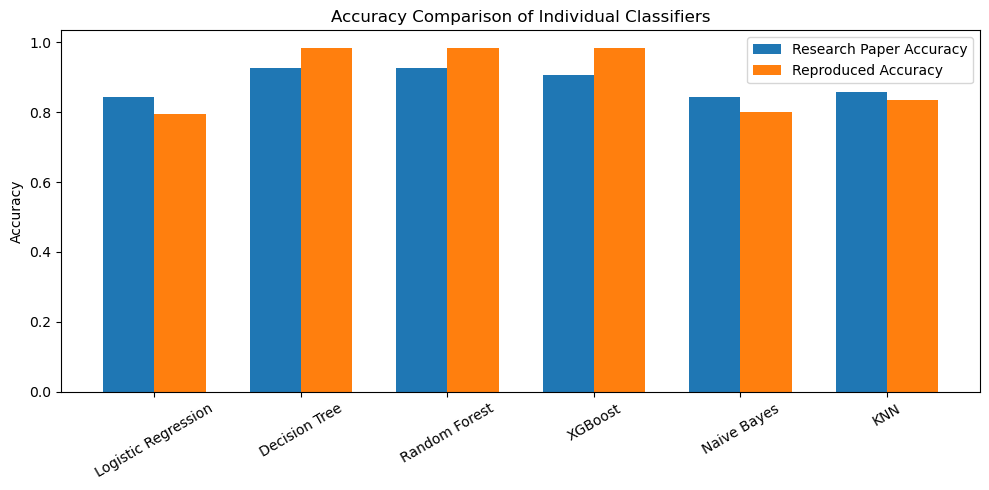

In [49]:
import numpy as np
import matplotlib.pyplot as plt

models = comparison_df["Model"]

paper_acc = comparison_df["Research Paper Accuracy"]
reproduced_acc = comparison_df["Reproduced Accuracy"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, paper_acc, width, label="Research Paper Accuracy")
plt.bar(x + width/2, reproduced_acc, width, label="Reproduced Accuracy")

plt.xticks(x, models, rotation=30)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Individual Classifiers")
plt.legend()
plt.tight_layout()
plt.show()

According to the result, the reproduced Decision Tree, Random Forest and XGBoost models can achieve higher accuracy than the accuracy score in the research paper. Meanwhile, the reproduced Logistic Regression, Naive Bayes and KNN models achieve a lower accuracy than the research paper result. This means that the reproduction does not affect all classifiers in the same way. In this, tree-based models can perform better in the reproduced setting, while Logistic Regression and probabilistic or distance-based models remained closer or lower than the research paper result. 

Then, the AUC score is also used to generate the graph. 

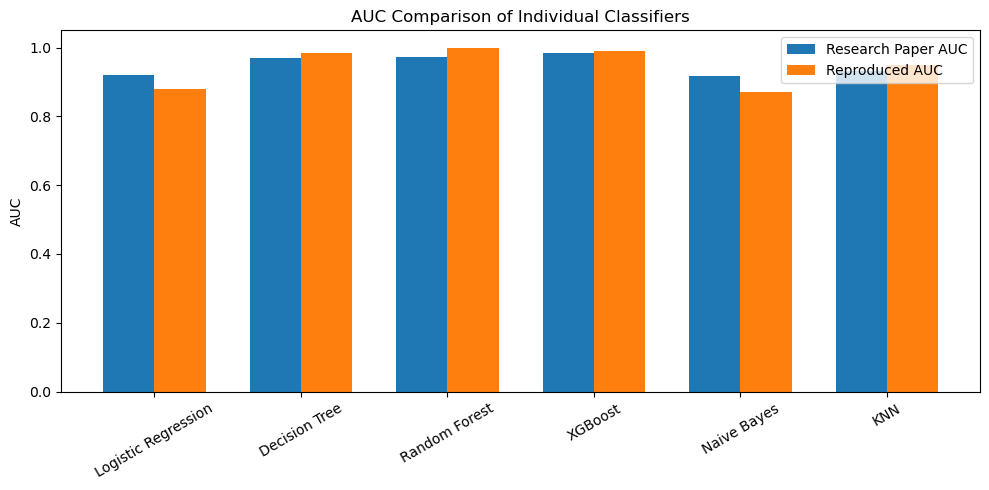

In [50]:
paper_auc = comparison_df["Research Paper AUC"]
reproduced_auc = comparison_df["Reproduced AUC"]

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, paper_auc, width, label="Research Paper AUC")
plt.bar(x + width/2, reproduced_auc, width, label="Reproduced AUC")

plt.xticks(x, models, rotation=30)
plt.ylabel("AUC")
plt.title("AUC Comparison of Individual Classifiers")
plt.legend()
plt.tight_layout()
plt.show()

The AUC comparison shows that the reproduced Decision Tree, Random Forest, XGBoost, and KNN models achieve higher AUC values than the result in the paper. However, the reproduced Logistic Regression and Naive Bayes models achieved lower AUC values.

## 4. Reproduction of the Stacking Ensemble

According to Bhagat et al. (2024), they combines 6 individual classifier by using a tacking ensemble. Stacking is an ensemble learning technique that combines multiple machine learning models to improve predictive performance. Different base models are trained first, and their predictions are then used as inputs for a higher-level model called a meta-model or meta-learner. The meta-model learns how to combine the outputs of the base models to produce the final prediction (GeeksforGeeks, 2019).


The research paper does not specify the exact meta-classifier used in the stacking ensemble. Therefore, the default settings of Stacking Classifer will be apply. According to scikit-learn (2019a), Logistic Regression is used as the final meta-classifier in the default setting. Then, a 5-fold cross-validation procedure is used to match the stacking setup reported in the paper.

In [51]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ("lr", LogisticRegression()),
    ("dt", DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )),
    ("rf", RandomForestClassifier(
        random_state=42
    )),
    ("xgb", XGBClassifier(
        random_state=42
    )),
    ("nb", GaussianNB()),
    ("knn", KNeighborsClassifier())
]

In [52]:
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

Then, the model will be trained by using the same scaled training dataset, which is used for 6 classifiers above. Then, 5-fold cross validation will be used to generate the base-modelf predictions for training the meta-classifier. 

In [53]:
stack_model.fit(X_train_scaled, y_train)

StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression()),
                               ('dt',
                                DecisionTreeClassifier(criterion='entropy',
                                                       random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              e...
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('nb', GaussianNB()),
                               ('knn', KNeighborsClassifier())],
                   final_estimator=LogisticRegression())

Then, the trained model will be use to predict. 

In [54]:
stack_pred = stack_model.predict(X_test_scaled)
stack_prob = stack_model.predict_proba(X_test_scaled)[:, 1]

After that, some similarity evaluation metrics is applied to evaluate the stacking classifer. 

In [55]:
stack_accuracy = accuracy_score(y_test, stack_pred)
stack_precision = precision_score(y_test, stack_pred)
stack_recall = recall_score(y_test, stack_pred)
stack_f1 = f1_score(y_test, stack_pred)
stack_auc = roc_auc_score(y_test, stack_prob)

print("Accuracy :", stack_accuracy)
print("Precision:", stack_precision)
print("Recall   :", stack_recall)
print("F1 Score :", stack_f1)
print("AUC      :", stack_auc)

Accuracy : 0.9853658536585366
Precision: 1.0
Recall   : 0.970873786407767
F1 Score : 0.9852216748768473
AUC      : 1.0


According to the result, the reproduced stacking ensemble can achieve an accuracy score at 98.54%, which is quite same to the research paper accuracy score at 98.53%. Then, precision is also similar at 1, while recall and f1 score are very close to the research paper values. Finally, the reproduced AUC score can reach value 1, which is slightly higher than the research AUC score at around 0.99. 

Then, I also generate the confusion matrix and ROC curve to have a comparision with the research paper results. 

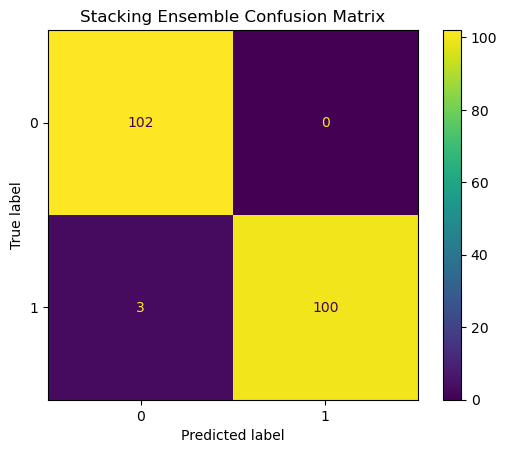

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    stack_pred
)

plt.title("Stacking Ensemble Confusion Matrix")
plt.show()

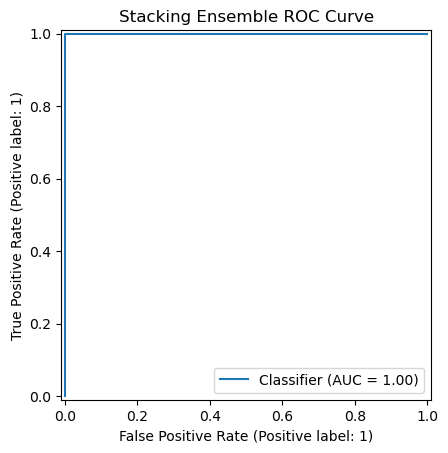

In [57]:
RocCurveDisplay.from_predictions(
    y_test,
    stack_prob
)

plt.title("Stacking Ensemble ROC Curve")
plt.show()

According to the results, the reproduced stacking confusion matrix shows 102 true negatives, 100 true positives, no any false positives, and only 3 false negatives. This pattern is very similar to the published confusion matrix, which also reports 0 false positives and 3 false negatives. Then, the reproduced stacking ensemble can also achieve the AUC score at 1, which is higher than the research paper AUC score. This means that the reproduced can have a better distinguish between 2 classes. 

Finally, the results of all 6 individual classifiers and the stacking ensemble will be summarised. The reproduced results are compared directly with the values reported in the research paper. 

In [58]:
stacking_row = {
    "Model": "Stacking",
    "Research Paper Accuracy": 0.9853,
    "Research Paper Precision": 1.0000,
    "Research Paper Recall": 0.9727,
    "Research Paper F1": 0.9861,
    "Research Paper AUC": 0.9880,
    "Reproduced Accuracy": stack_accuracy,
    "Reproduced Precision": stack_precision,
    "Reproduced Recall": stack_recall,
    "Reproduced F1": stack_f1,
    "Reproduced AUC": stack_auc
}

final_comparison_df = pd.concat(
    [comparison_df, pd.DataFrame([stacking_row])],
    ignore_index=True
)

final_comparison_df.round(4)

,Model,Research Paper Accuracy,Research Paper Precision,Research Paper Recall,Research Paper F1,Research Paper AUC,Reproduced Accuracy,Reproduced Precision,Reproduced Recall,Reproduced F1,Reproduced AUC
0,Logistic Regression,0.8439,0.8196,0.9090,0.8620,0.9204,0.7951,0.7563,0.8738,0.8108,0.8787
1,Decision Tree,0.9268,0.9702,0.8909,0.9289,0.9702,0.9854,1.0000,0.9709,0.9852,0.9854
2,Random Forest,0.9268,0.9130,0.9545,0.9333,0.9734,0.9854,1.0000,0.9709,0.9852,1.0000
3,XGBoost,0.9073,0.9174,0.9090,0.9132,0.9830,0.9854,1.0000,0.9709,0.9852,0.9894
4,Naive Bayes,0.8439,0.8250,0.9000,0.8608,0.9185,0.8000,0.7541,0.8932,0.8178,0.8706
5,KNN,0.8585,0.8648,0.8727,0.8687,0.9304,0.8341,0.8000,0.8932,0.8440,0.9486
6,Stacking,0.9853,1.0000,0.9727,0.9861,0.9880,0.9854,1.0000,0.9709,0.9852,1.0000


The accuracy graph is also generated to have an easier comparision. 

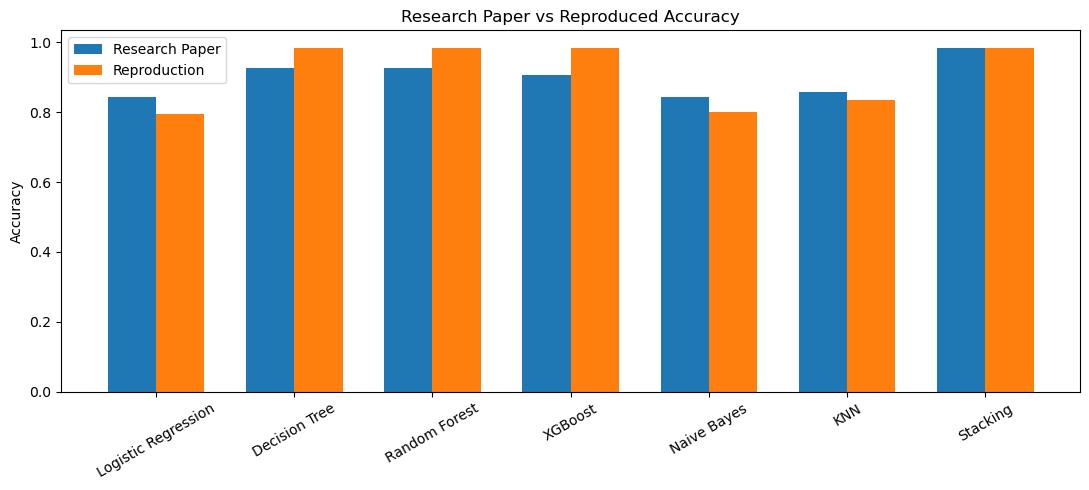

In [59]:
models = final_comparison_df["Model"]

paper_acc = final_comparison_df["Research Paper Accuracy"]
reproduced_acc = final_comparison_df["Reproduced Accuracy"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(11, 5))

plt.bar(
    x - width/2,
    paper_acc,
    width,
    label="Research Paper"
)

plt.bar(
    x + width/2,
    reproduced_acc,
    width,
    label="Reproduction"
)

plt.xticks(x, models, rotation=30)
plt.ylabel("Accuracy")
plt.title("Research Paper vs Reproduced Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

According to the accuracy graph, Logistic Regression, Naive Bayes, and KNN achieved lower reproduced accuracy than reported in the paper. Meanwhile, Decision Tree, Random Forest, and XGBoost achieved substantially higher reproduced accuracy. Then, the stacking ensemble shows the closest agreement with the research paper result, which can achieve 98.54% accuracy compared with the 98.53% in the research paper. This means that the overall stacking result is successfully reproduced. 

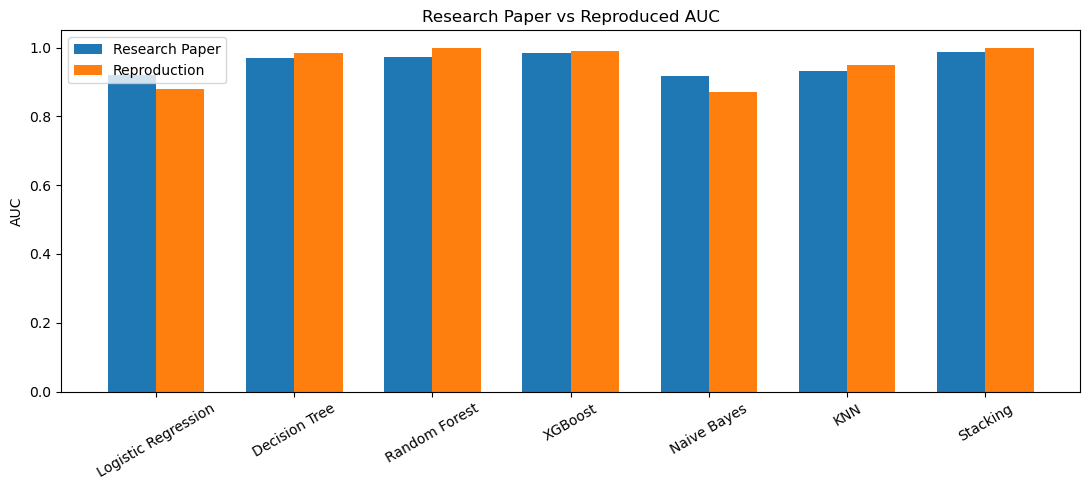

In [60]:
paper_auc = final_comparison_df["Research Paper AUC"]
reproduced_auc = final_comparison_df["Reproduced AUC"]

plt.figure(figsize=(11, 5))

plt.bar(
    x - width/2,
    paper_auc,
    width,
    label="Research Paper"
)

plt.bar(
    x + width/2,
    reproduced_auc,
    width,
    label="Reproduction"
)

plt.xticks(x, models, rotation=30)
plt.ylabel("AUC")
plt.title("Research Paper vs Reproduced AUC")
plt.legend()
plt.tight_layout()
plt.show()

The reproduced AUC results also show differences across the classifiers. Logistic Regression and Naive Bayes achieved lower AUC values than reported in the paper, while Decision Tree, Random Forest, XGBoost, and KNN achieved higher values. The reproduced stacking ensemble achieved an AUC of 1.00 compared with the published value of 0.9880.

## 5. Critical Analysis of the Reproduction

First, a large number of duplicated records is identified during dataset inspection. Because the research paper uses all 1025 record dataset and does not report removing duplicates, which is still kept in the reproduction. Therefore, the training and testing sets will be checked for identical records in both set to investigate whether duplication affect the reproduced results. 

In [61]:
train_check = X_train.copy()
train_check["target"] = y_train

test_check = X_test.copy()
test_check["target"] = y_test

train_unique = train_check.drop_duplicates()

overlap = test_check.merge(
    train_unique,
    how="inner",
    on=list(train_check.columns)
)

print("Test samples:", len(test_check))
print("Test samples also found in training:", len(overlap))
print(
    "Percentage of test samples also found in training:",
    len(overlap) / len(test_check) * 100
)

Test samples: 205
Test samples also found in training: 199
Percentage of test samples also found in training: 97.07317073170731


According to the result, 199/205 test samples have an identical record in the training set. This means that most test observations are not idependent from the training data under the current random split. Therefore, duplicated records may expand the reproduced performance. For example, in tree-based models and stacking ensemble, it can achieve nearly same results. However, other differences such as assumption random seed and model hyperparameters can also contribute to the discrepancy with the research paper. 

Then, a supplementary dataset is created by removing exact duplicate rows to investigate the impace of duplication. 

In [62]:
df_unique = df.drop_duplicates()

print("Original dataset shape:", df.shape)
print("Unique dataset shape:", df_unique.shape)

Original dataset shape: (1025, 14)
Unique dataset shape: (302, 14)


Then, the new dataset will be split into features and target variable. 

In [63]:
X_unique = df_unique.drop("target", axis=1)
y_unique = df_unique["target"]

print("X shape:", X_unique.shape)
print("y shape:", y_unique.shape)

X shape: (302, 13)
y shape: (302,)


To make the diagnostic experiment comparable with the main reproduction, the same 80:20 train-test split, random state, and scaling procedure are retained.

In [64]:
X_train_unique, X_test_unique, y_train_unique, y_test_unique = train_test_split(
    X_unique,
    y_unique,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train_unique.shape[0])
print("Testing samples:", X_test_unique.shape[0])

Training samples: 241
Testing samples: 61


The new unique dataset is also scaled with the same scaling method with the reproduction. 

In [65]:
scaler_unique = StandardScaler()

X_train_unique_scaled = scaler_unique.fit_transform(X_train_unique)
X_test_unique_scaled = scaler_unique.transform(X_test_unique)

print(X_train_unique_scaled.shape)
print(X_test_unique_scaled.shape)

(241, 13)
(61, 13)


In [66]:
train_unique_check = X_train_unique.copy()
train_unique_check["target"] = y_train_unique

test_unique_check = X_test_unique.copy()
test_unique_check["target"] = y_test_unique

overlap_unique = test_unique_check.merge(
    train_unique_check,
    how="inner",
    on=list(train_unique_check.columns)
)

print("Test samples:", len(test_unique_check))
print("Test samples also found in training:", len(overlap_unique))

Test samples: 61
Test samples also found in training: 0


According to the result, the new version dataset does not contain any train-test overlap. Therefore, I will start to use this unique dataset to train the new Decision Tree model with the same hyperparameter settings. 

### Decision Tree

In [67]:
dt_unique = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_unique.fit(X_train_unique_scaled, y_train_unique)

dt_unique_pred = dt_unique.predict(X_test_unique_scaled)
dt_unique_prob = dt_unique.predict_proba(X_test_unique_scaled)[:, 1]

In [68]:
dt_unique_accuracy = accuracy_score(y_test_unique, dt_unique_pred)
dt_unique_precision = precision_score(y_test_unique, dt_unique_pred)
dt_unique_recall = recall_score(y_test_unique, dt_unique_pred)
dt_unique_f1 = f1_score(y_test_unique, dt_unique_pred)
dt_unique_auc = roc_auc_score(y_test_unique, dt_unique_prob)

print("Accuracy :", dt_unique_accuracy)
print("Precision:", dt_unique_precision)
print("Recall   :", dt_unique_recall)
print("F1 Score :", dt_unique_f1)
print("AUC      :", dt_unique_auc)

Accuracy : 0.7213114754098361
Precision: 0.6875
Recall   : 0.7586206896551724
F1 Score : 0.7213114754098361
AUC      : 0.7230603448275862


In [69]:
dt_diagnostic_comparison = pd.DataFrame({
    "Experiment": [
        "Research Paper",
        "Main Reproduction",
        "Unique Dataset Diagnostic"
    ],
    "Accuracy": [
        0.9268,
        dt_accuracy,
        dt_unique_accuracy
    ],
    "Precision": [
        0.9702,
        dt_precision,
        dt_unique_precision
    ],
    "Recall": [
        0.8909,
        dt_recall,
        dt_unique_recall
    ],
    "F1": [
        0.9289,
        dt_f1,
        dt_unique_f1
    ],
    "AUC": [
        0.9702,
        dt_auc,
        dt_unique_auc
    ]
})

dt_diagnostic_comparison.round(4)

,Experiment,Accuracy,Precision,Recall,F1,AUC
0,Research Paper,0.9268,0.9702,0.8909,0.9289,0.9702
1,Main Reproduction,0.9854,1.0000,0.9709,0.9852,0.9854
2,Unique Dataset Diagnostic,0.7213,0.6875,0.7586,0.7213,0.7231


According to the result of the comparision table, the accuracy score decreases from 98.54% in the main reproduction to 72.13% in the unique dataset version, while the AUC decreases from 0.9854 to 0.7231. This means that the duplication in the original dataset have a strong effect on Decision Tree performance.

### Random Forest

Then, the Random Forest is trained by using the unique dataset with the same hyperparameter with the reproduced Random Forest model. 

In [70]:
rf_unique = RandomForestClassifier(
    random_state=42
)

rf_unique.fit(X_train_unique_scaled, y_train_unique)

rf_unique_pred = rf_unique.predict(X_test_unique_scaled)
rf_unique_prob = rf_unique.predict_proba(X_test_unique_scaled)[:, 1]

In [71]:
rf_unique_accuracy = accuracy_score(y_test_unique, rf_unique_pred)
rf_unique_precision = precision_score(y_test_unique, rf_unique_pred)
rf_unique_recall = recall_score(y_test_unique, rf_unique_pred)
rf_unique_f1 = f1_score(y_test_unique, rf_unique_pred)
rf_unique_auc = roc_auc_score(y_test_unique, rf_unique_prob)

print("Accuracy :", rf_unique_accuracy)
print("Precision:", rf_unique_precision)
print("Recall   :", rf_unique_recall)
print("F1 Score :", rf_unique_f1)
print("AUC      :", rf_unique_auc)

Accuracy : 0.8360655737704918
Precision: 0.7878787878787878
Recall   : 0.896551724137931
F1 Score : 0.8387096774193549
AUC      : 0.878771551724138


In [72]:
rf_diagnostic_comparison = pd.DataFrame({
    "Experiment": [
        "Research Paper",
        "Main Reproduction",
        "Unique Dataset Diagnostic"
    ],
    "Accuracy": [
        0.9268,
        rf_accuracy,
        rf_unique_accuracy
    ],
    "Precision": [
        0.9130,
        rf_precision,
        rf_unique_precision
    ],
    "Recall": [
        0.9545,
        rf_recall,
        rf_unique_recall
    ],
    "F1": [
        0.9333,
        rf_f1,
        rf_unique_f1
    ],
    "AUC": [
        0.9734,
        rf_auc,
        rf_unique_auc
    ]
})

rf_diagnostic_comparison.round(4)

,Experiment,Accuracy,Precision,Recall,F1,AUC
0,Research Paper,0.9268,0.9130,0.9545,0.9333,0.9734
1,Main Reproduction,0.9854,1.0000,0.9709,0.9852,1.0000
2,Unique Dataset Diagnostic,0.8361,0.7879,0.8966,0.8387,0.8788


According to the result, the Random Forst using unique dataset decreases from 98.54% to 83.61%, while AUC score decreases from 1 to 0.8788. This means that the Random Forest results became considerably lower after removing duplicate records in the original dataset. 

### XGBoost

Then, the XGBoost model will be also trained with the unique dataset, while using the same hyperparameter settings. 

In [73]:
xgb_unique = XGBClassifier(
    random_state=42
)

xgb_unique.fit(X_train_unique_scaled, y_train_unique)

xgb_unique_pred = xgb_unique.predict(X_test_unique_scaled)
xgb_unique_prob = xgb_unique.predict_proba(X_test_unique_scaled)[:, 1]

In [74]:
xgb_unique_accuracy = accuracy_score(y_test_unique, xgb_unique_pred)
xgb_unique_precision = precision_score(y_test_unique, xgb_unique_pred)
xgb_unique_recall = recall_score(y_test_unique, xgb_unique_pred)
xgb_unique_f1 = f1_score(y_test_unique, xgb_unique_pred)
xgb_unique_auc = roc_auc_score(y_test_unique, xgb_unique_prob)

print("Accuracy :", xgb_unique_accuracy)
print("Precision:", xgb_unique_precision)
print("Recall   :", xgb_unique_recall)
print("F1 Score :", xgb_unique_f1)
print("AUC      :", xgb_unique_auc)

Accuracy : 0.8032786885245902
Precision: 0.7575757575757576
Recall   : 0.8620689655172413
F1 Score : 0.8064516129032258
AUC      : 0.8523706896551724


In [75]:
xgb_diagnostic_comparison = pd.DataFrame({
    "Experiment": [
        "Research Paper",
        "Main Reproduction",
        "Unique Dataset Diagnostic"
    ],
    "Accuracy": [
        0.9073,
        xgb_accuracy,
        xgb_unique_accuracy
    ],
    "Precision": [
        0.9174,
        xgb_precision,
        xgb_unique_precision
    ],
    "Recall": [
        0.9090,
        xgb_recall,
        xgb_unique_recall
    ],
    "F1": [
        0.9132,
        xgb_f1,
        xgb_unique_f1
    ],
    "AUC": [
        0.9830,
        xgb_auc,
        xgb_unique_auc
    ]
})

xgb_diagnostic_comparison.round(4)

,Experiment,Accuracy,Precision,Recall,F1,AUC
0,Research Paper,0.9073,0.9174,0.9090,0.9132,0.9830
1,Main Reproduction,0.9854,1.0000,0.9709,0.9852,0.9894
2,Unique Dataset Diagnostic,0.8033,0.7576,0.8621,0.8065,0.8524


According to the result, the XGBoost performance also decreased after duplicate records were removed. Accuracy score drops from 98.54% in the main reproduction to 80.33%, while AUC decreases from 0.9894 to 0.8524.


### Stacking Ensemble

Finally, the Stacking Ensemble will be trained by using the unique dataset with the same 6 base classifier, Logistic Regression meta-classifier and 5-fold stacking procedure as the main reproduction. 

In [76]:
estimators_unique = [
    ("lr", LogisticRegression()),
    ("dt", DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )),
    ("rf", RandomForestClassifier(
        random_state=42
    )),
    ("xgb", XGBClassifier(
        random_state=42
    )),
    ("nb", GaussianNB()),
    ("knn", KNeighborsClassifier())
]

stack_unique = StackingClassifier(
    estimators=estimators_unique,
    final_estimator=LogisticRegression(),
    cv=5
)

stack_unique.fit(X_train_unique_scaled, y_train_unique)

StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression()),
                               ('dt',
                                DecisionTreeClassifier(criterion='entropy',
                                                       random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              e...
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('nb', GaussianNB()),
                               ('knn', KNeighborsClassifier())],
                   final_estimator=LogisticRegression())

In [77]:
stack_unique_pred = stack_unique.predict(X_test_unique_scaled)
stack_unique_prob = stack_unique.predict_proba(X_test_unique_scaled)[:, 1]

In [78]:
stack_unique_accuracy = accuracy_score(y_test_unique, stack_unique_pred)
stack_unique_precision = precision_score(y_test_unique, stack_unique_pred)
stack_unique_recall = recall_score(y_test_unique, stack_unique_pred)
stack_unique_f1 = f1_score(y_test_unique, stack_unique_pred)
stack_unique_auc = roc_auc_score(y_test_unique, stack_unique_prob)

print("Accuracy :", stack_unique_accuracy)
print("Precision:", stack_unique_precision)
print("Recall   :", stack_unique_recall)
print("F1 Score :", stack_unique_f1)
print("AUC      :", stack_unique_auc)

Accuracy : 0.8360655737704918
Precision: 0.7878787878787878
Recall   : 0.896551724137931
F1 Score : 0.8387096774193549
AUC      : 0.8685344827586207


Then, I will create the final tables, which compares the research paper, reproduction with full records dataset and the unique free dataset models. 

In [79]:
diagnostic_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree", "Decision Tree", "Decision Tree",
        "Random Forest", "Random Forest", "Random Forest",
        "XGBoost", "XGBoost", "XGBoost",
        "Stacking", "Stacking", "Stacking"
    ],
    
    "Experiment": [
        "Research Paper", "Main Reproduction", "Unique Dataset",
        "Research Paper", "Main Reproduction", "Unique Dataset",
        "Research Paper", "Main Reproduction", "Unique Dataset",
        "Research Paper", "Main Reproduction", "Unique Dataset"
    ],
    
    "Accuracy": [
        0.9268, dt_accuracy, dt_unique_accuracy,
        0.9268, rf_accuracy, rf_unique_accuracy,
        0.9073, xgb_accuracy, xgb_unique_accuracy,
        0.9853, stack_accuracy, stack_unique_accuracy
    ],
    
    "Precision": [
        0.9702, dt_precision, dt_unique_precision,
        0.9130, rf_precision, rf_unique_precision,
        0.9174, xgb_precision, xgb_unique_precision,
        1.0000, stack_precision, stack_unique_precision
    ],
    
    "Recall": [
        0.8909, dt_recall, dt_unique_recall,
        0.9545, rf_recall, rf_unique_recall,
        0.9090, xgb_recall, xgb_unique_recall,
        0.9727, stack_recall, stack_unique_recall
    ],
    
    "F1": [
        0.9289, dt_f1, dt_unique_f1,
        0.9333, rf_f1, rf_unique_f1,
        0.9132, xgb_f1, xgb_unique_f1,
        0.9861, stack_f1, stack_unique_f1
    ],
    
    "AUC": [
        0.9702, dt_auc, dt_unique_auc,
        0.9734, rf_auc, rf_unique_auc,
        0.9830, xgb_auc, xgb_unique_auc,
        0.9880, stack_auc, stack_unique_auc
    ]
})

diagnostic_comparison.round(4)

,Model,Experiment,Accuracy,Precision,Recall,F1,AUC
0,Decision Tree,Research Paper,0.9268,0.9702,0.8909,0.9289,0.9702
1,Decision Tree,Main Reproduction,0.9854,1.0000,0.9709,0.9852,0.9854
2,Decision Tree,Unique Dataset,0.7213,0.6875,0.7586,0.7213,0.7231
3,Random Forest,Research Paper,0.9268,0.9130,0.9545,0.9333,0.9734
4,Random Forest,Main Reproduction,0.9854,1.0000,0.9709,0.9852,1.0000
5,Random Forest,Unique Dataset,0.8361,0.7879,0.8966,0.8387,0.8788
6,XGBoost,Research Paper,0.9073,0.9174,0.9090,0.9132,0.9830
7,XGBoost,Main Reproduction,0.9854,1.0000,0.9709,0.9852,0.9894
8,XGBoost,Unique Dataset,0.8033,0.7576,0.8621,0.8065,0.8524
9,Stacking,Research Paper,0.9853,1.0000,0.9727,0.9861,0.9880


Then, I will also create the accuracy graph to have an evaluation. 

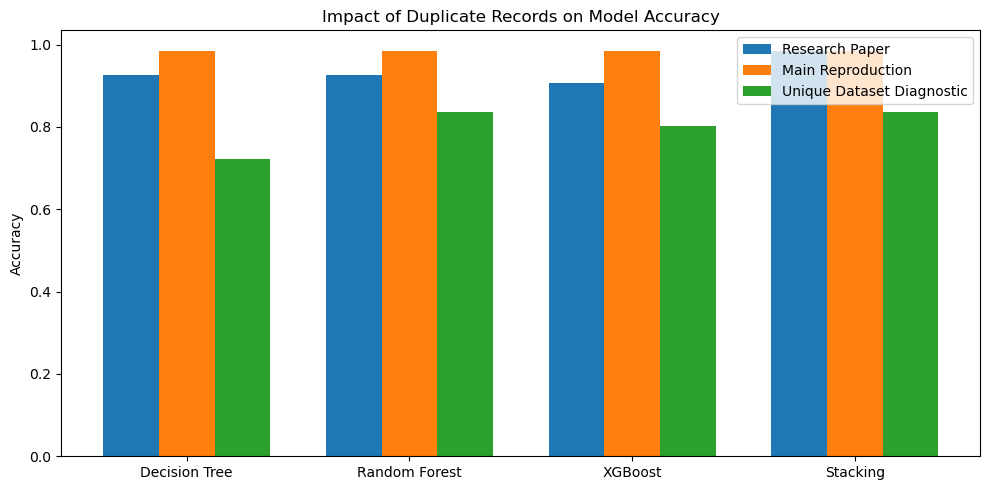

In [80]:
models_diag = [
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Stacking"
]

paper_accuracy = [
    0.9268,
    0.9268,
    0.9073,
    0.9853
]

main_accuracy = [
    dt_accuracy,
    rf_accuracy,
    xgb_accuracy,
    stack_accuracy
]

unique_accuracy = [
    dt_unique_accuracy,
    rf_unique_accuracy,
    xgb_unique_accuracy,
    stack_unique_accuracy
]

x = np.arange(len(models_diag))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    x - width,
    paper_accuracy,
    width,
    label="Research Paper"
)

plt.bar(
    x,
    main_accuracy,
    width,
    label="Main Reproduction"
)

plt.bar(
    x + width,
    unique_accuracy,
    width,
    label="Unique Dataset Diagnostic"
)

plt.xticks(x, models_diag)
plt.ylabel("Accuracy")
plt.title("Impact of Duplicate Records on Model Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

According to all the results above, the main reproduction can successfully reproduce the reseach stacking classifier result, which can achieve 98.54% accuracy compared with the reported 98.53% in the research paper. However, several tree-based models also achieve high performance in the reproduction. 

Then, the critical analysis remove 723 duplicated rows in the dataset and use the same train-test split, scaling method and hyperparameter setting. This make the performance decreases across all investigated models. For example, Decision Tree accuracy decrease from 98.54% to 72.13%, while Random Forest, XGBoost and Stacking decrease to around 83.61%, 80.33% and 83.61%, respectively. These results provide a strong evidence that duplicated records in the original dataset can affect the performance in the main reproduction. However, the unique experiment is treated only as a diagnostic analysis and does not replace the main reproduction. 

# Part 2: Build Your Own ML Solution

## 1. Motivation and Identified Limitation

The critical analysis in Part 1 identified the significant duplication in the original dataset. In the original dataset, 723 duplicated rows are identified in total 1025 records. Under the reproduced random train-test split, 199/205 test samples had an identical observation in the training set. This overlap reduces the idependence of the test set may expand the measured predictive performance. This concern is supported by the unique diagnostic experiment, where performance of Decision Tree, Random Forest, XGBoost and the stacking ensemble decrease significantly. 

Therefore, in this part, the robust evaluation pipeline that remove exact duplicate observations and evaluates the stacking ensemble by using repeated stratified cross-validation.

The proposed method is a Robust Duplicate Aware Stacking Pipeline. This method will first remove the duplicate rows before model evaluation. Then, the remaining unique records are evaluated by using Repeated Stratified 5-Fold Cross-Validation instead of relying on a single train-test split. According to GeeksforGeeks (2020), Stratified K-Fold Cross-Validation divides the dataset into multiple folds while maintaining approximately the same class distribution in each fold as in the original dataset. This can provide a more consistent evaluation than a single random train-test split because each fold contains a representative proportion of the target classes. Therefore, in this proposed method, I will extend this idea by repeating the stratified K-Fold process several times with different data partitions. This allows the stacking model to be evaluated across multiple training and testing combinations instead of relying on only one split. For this experiment, I will use 5-fold stratified cross-validation repeated 5 times, producing 25 evaluation results. The mean and standard deviation of Accuracy, Precision, Recall, F1 Score, and AUC will then be used to evaluate the robustness of the proposed method.

Removing exact duplicate records is expected to improve the separation between training and testing data. Repeated stratified evaluation is also expected to reduce the dependence of the reported performance on a single random data split and provide information about performance variability across different partitions.

As a result, Exact duplicate records are removed before evaluation so that identical observations cannot appear in both the training and testing folds.

In [81]:
proposed_df = df.drop_duplicates().copy()

print("Original records:", len(df))
print("Unique records:", len(proposed_df))
print("Removed duplicates:", len(df) - len(proposed_df))

Original records: 1025
Unique records: 302
Removed duplicates: 723


Then, I will check the target distribution after removing duplicated records. 

In [82]:
proposed_df["target"].value_counts()


target
1    164
0    138
Name: count, dtype: int64

In [83]:
proposed_df["target"].value_counts(normalize=True) * 100

target
1    54.304636
0    45.695364
Name: proportion, dtype: float64

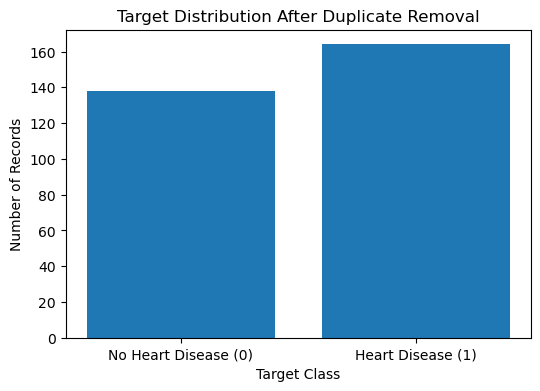

In [84]:
proposed_target_counts = proposed_df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["No Heart Disease (0)", "Heart Disease (1)"],
    proposed_target_counts.values
)
plt.xlabel("Target Class")
plt.ylabel("Number of Records")
plt.title("Target Distribution After Duplicate Removal")
plt.show()

According to the result, the target distribution remains quite balanced with 54.30% of records, which belong to the heart disease class and 45.70% belonging to the no heart disease class. 

Then, the predictor features and target variable will be separated before evaluation. The proposed method uses Repeated Stratified 5-Fold Cross-Validation with 5 repeats. According to Scikit-Learn (2024), Repeated Stratified K-Fold is a cross-validation method that repeats Stratified K-Fold several times with different randomised partitions. The stratification is based on the target labels, so each fold maintains the class distribution of the dataset. Therefore, each 5-fold cycle divides the dataset into five folds while maintaining the same target-class distribution in each fold. The process is repeated 5 times using different partitions, producing 25 outer evaluation folds in total.

In [85]:
from sklearn.model_selection import RepeatedStratifiedKFold

In [86]:
X_proposed = proposed_df.drop("target", axis=1)
y_proposed = proposed_df["target"]

outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

print("Feature shape:", X_proposed.shape)
print("Target shape:", y_proposed.shape)
print("Total evaluation folds:", 5 * 5)

Feature shape: (302, 13)
Target shape: (302,)
Total evaluation folds: 25


Then, the proposed evaluation retains the same six base classifiers and stacking structure used in Part 1 so that the predictive models themselves are not changed. Because cross-validation repeatedly creates different training and testing folds, feature scaling must be fitted only using the training data available to each model. Therefore, StandardScaler is included inside each model pipeline rather than being fitted once on the complete proposed dataset.

In [87]:
from sklearn.pipeline import Pipeline

In [88]:
proposed_estimators = [
    (
        "lr",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression())
        ])
    ),
    
    (
        "dt",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", DecisionTreeClassifier(
                criterion="entropy",
                random_state=42
            ))
        ])
    ),
    
    (
        "rf",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestClassifier(
                random_state=42
            ))
        ])
    ),
    
    (
        "xgb",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", XGBClassifier(
                random_state=42
            ))
        ])
    ),
    
    (
        "nb",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", GaussianNB())
        ])
    ),
    
    (
        "knn",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ])
    )
]

After that, the same 5-fold stacking structure from part 1 is reused. Logistic Regression will be used as the meta-classifier. 

In [89]:
proposed_stack = StackingClassifier(
    estimators=proposed_estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

proposed_stack

StackingClassifier(cv=5,
                   estimators=[('lr',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 LogisticRegression())])),
                               ('dt',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 DecisionTreeClassifier(criterion='entropy',
                                                                        random_state=42))])),
                               ('rf',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 RandomForestClassifier(random_state=42))])),
                               ('xg...
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=None,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...))])),
                               ('nb',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model', GaussianNB())])),
                               ('knn',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 KNeighborsClassifier())]))],
                   final_estimator=LogisticRegression())

The outer repeated stratified cross-validation is used to estimate generalisation performance, while the internal 5-fold cross-validation is retained as part of the stacking procedure. These two validation levels therefore serve different purposes.

Then, the proposed stacking model is evaluated by using 25 outer folds, which is generated by Repeated Stratified 5-fold Cross Validation. For each outer fold, the model is trined only on the training portion and evaluated on the unseen test portion. 

In [90]:
from sklearn.base import clone

In [91]:
proposed_results = []

for i, (train_index, test_index) in enumerate(
    outer_cv.split(X_proposed, y_proposed), start=1
):
    X_train_fold = X_proposed.iloc[train_index]
    X_test_fold = X_proposed.iloc[test_index]

    y_train_fold = y_proposed.iloc[train_index]
    y_test_fold = y_proposed.iloc[test_index]

    fold_model = clone(proposed_stack)

    fold_model.fit(X_train_fold, y_train_fold)

    y_pred_fold = fold_model.predict(X_test_fold)
    y_prob_fold = fold_model.predict_proba(X_test_fold)[:, 1]

    fold_accuracy = accuracy_score(y_test_fold, y_pred_fold)
    fold_precision = precision_score(y_test_fold, y_pred_fold)
    fold_recall = recall_score(y_test_fold, y_pred_fold)
    fold_f1 = f1_score(y_test_fold, y_pred_fold)
    fold_auc = roc_auc_score(y_test_fold, y_prob_fold)

    repeat_number = ((i - 1) // 5) + 1
    fold_number = ((i - 1) % 5) + 1

    proposed_results.append({
        "Repeat": repeat_number,
        "Fold": fold_number,
        "Accuracy": fold_accuracy,
        "Precision": fold_precision,
        "Recall": fold_recall,
        "F1": fold_f1,
        "AUC": fold_auc
    })

In [92]:
proposed_results_df = pd.DataFrame(proposed_results)

proposed_results_df.round(4)

,Repeat,Fold,Accuracy,Precision,Recall,F1,AUC
0,1,1,0.8033,0.8621,0.7576,0.8065,0.8820
1,1,2,0.8033,0.7561,0.9394,0.8378,0.9307
2,1,3,0.8333,0.8438,0.8438,0.8438,0.9096
3,1,4,0.9000,0.8649,0.9697,0.9143,0.9158
4,1,5,0.8167,0.8056,0.8788,0.8406,0.9068
5,2,1,0.8525,0.9000,0.8182,0.8571,0.9426
6,2,2,0.8689,0.8205,0.9697,0.8889,0.9015
7,2,3,0.7833,0.7436,0.9062,0.8169,0.8705
8,2,4,0.8833,0.9062,0.8788,0.8923,0.9080
9,2,5,0.7833,0.7500,0.9091,0.8219,0.8597


According to the result, the stacking model shows noticeable performance variation across the 25 outer evaluation folds. Accuracy ranges from around 76.67% to 91.67%, while AUC range from around 0.86 to 0.98. Then, precison, recall and f1 score also fluctuate between folds, which shows that the model performance is affected by different training and testing partition after duplicates values are removed. 

Therefore, the final perfomance is summarised by using the mean and standard deviation of Accuracy, Precision, Recall, F1 Score and AUC score. The mean value represent for the average predictive performance across repeated evaluation, while the standard deviation shows how much the result varies between different data partitions. 

In [93]:
metric_columns = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

proposed_summary = pd.DataFrame({
    "Mean": proposed_results_df[metric_columns].mean(),
    "Standard Deviation": proposed_results_df[metric_columns].std()
})

proposed_summary.round(4)

,Mean,Standard Deviation
Accuracy,0.8284,0.0373
Precision,0.8240,0.0519
Recall,0.8768,0.0622
F1,0.8472,0.0336
AUC,0.9050,0.0295


In [94]:
proposed_summary_display = pd.DataFrame({
    "Metric": metric_columns,
    "Mean ± SD": [
        f"{proposed_results_df[m].mean():.4f} ± {proposed_results_df[m].std():.4f}"
        for m in metric_columns
    ]
})

proposed_summary_display

,Metric,Mean ± SD
0,Accuracy,0.8284 ± 0.0373
1,Precision,0.8240 ± 0.0519
2,Recall,0.8768 ± 0.0622
3,F1,0.8472 ± 0.0336
4,AUC,0.9050 ± 0.0295


{'whiskers': [<matplotlib.lines.Line2D at 0x17b86f022d0>,
 'caps': [<matplotlib.lines.Line2D at 0x17b86f027e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x17b86ec7830>,
 'medians': [<matplotlib.lines.Line2D at 0x17b86f02de0>,
 'fliers': [<matplotlib.lines.Line2D at 0x17b86f03380>,
 'means': [<matplotlib.lines.Line2D at 0x17b86f030e0>,
  <matplotlib.lines.Line2D at 0x17b871644a0>]}

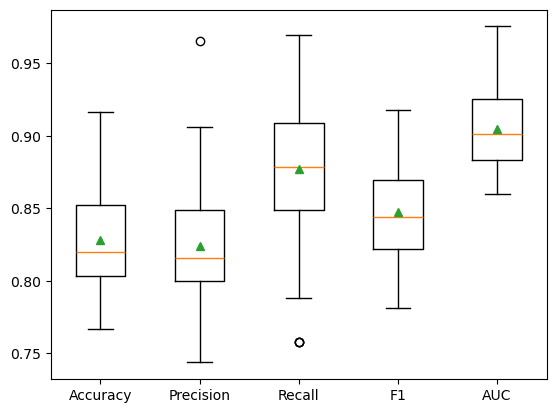

In [95]:
plt.boxplot(
    [
        proposed_results_df["Accuracy"],
        proposed_results_df["Precision"],
        proposed_results_df["Recall"],
        proposed_results_df["F1"],
        proposed_results_df["AUC"]
    ],
    tick_labels=["Accuracy", "Precision", "Recall", "F1", "AUC"],
    showmeans=True
)

According to the result, the propsed stacking method can achieve a mean Accuracy at 0.8284 ± 0.0373, Precision at 0.8240 ± 0.0519, Recall of 87.68% ± 6.22%, F1 Score of 84.72% ± 3.36%, and AUC of 90.50% ± 2.95%. In this, Recall can achieve the highest average value, which means that the model is effective at identifying positive heart disease cases. Then, the mean AUC score at 0.9050 demonstrates a good overall class distinguish across the repeated evaluations. The standard deviations show that performance changes between different data partitions, particularly for Precision and Recall. Therefore, reporting the mean and standard deviation across repeated folds provides a more informative estimate of model performance than relying on a single train-test split.

Finally, the proposed method is compared with 3 previous results, which are result in selected research paper, main reproduction from part 1, unique dataset diagnostic experiment from part 1. 

In [96]:
final_part2_comparison = pd.DataFrame({
    "Method": [
        "Research Paper",
        "Part 1 Reproduction",
        "Part 1 Unique Dataset Diagnostic",
        "Part 2 Proposed Method"
    ],

    "Accuracy": [
        0.9853,
        stack_accuracy,
        stack_unique_accuracy,
        proposed_results_df["Accuracy"].mean()
    ],

    "Precision": [
        1.0000,
        stack_precision,
        stack_unique_precision,
        proposed_results_df["Precision"].mean()
    ],

    "Recall": [
        0.9727,
        stack_recall,
        stack_unique_recall,
        proposed_results_df["Recall"].mean()
    ],

    "F1": [
        0.9861,
        stack_f1,
        stack_unique_f1,
        proposed_results_df["F1"].mean()
    ],

    "AUC": [
        0.9880,
        stack_auc,
        stack_unique_auc,
        proposed_results_df["AUC"].mean()
    ]
})

final_part2_comparison.round(4)

,Method,Accuracy,Precision,Recall,F1,AUC
0,Research Paper,0.9853,1.0000,0.9727,0.9861,0.9880
1,Part 1 Reproduction,0.9854,1.0000,0.9709,0.9852,1.0000
2,Part 1 Unique Dataset Diagnostic,0.8361,0.7879,0.8966,0.8387,0.8685
3,Part 2 Proposed Method,0.8284,0.8240,0.8768,0.8472,0.9050


According to the result, the main Part 1 reproduction closely matches the research paper stacking accuracy, with 98.54% compared with 98.53% in the research paper. However, both results are significant higher than the unique dataset evaluations. The duplicate removed single-split diagnostic achieves 83.61% accuracy, while the proposed repeated evaluation produces a mean accuracy of 82.84%. These similar values provide additional evidence that the lower performance is not limited to one particular unique dataset train-test split. The proposed method achieves slightly lower mean accuracy than the unique dataset diagnostic, but it produced higher mean Precision, F1 and AUC than the single critical diagnostic. Moreover, it evaluates the model across 25 stratified test folds rather than relying on one random split. Therefore, the main improvement of the proposed method is not a higher raw accuracy than the published result, but a more robust more robust estimate of model generalisation.



Then, I also visualize the effect of the methodological changes, which includes Accuracy nd AUC to compare with previous one. 

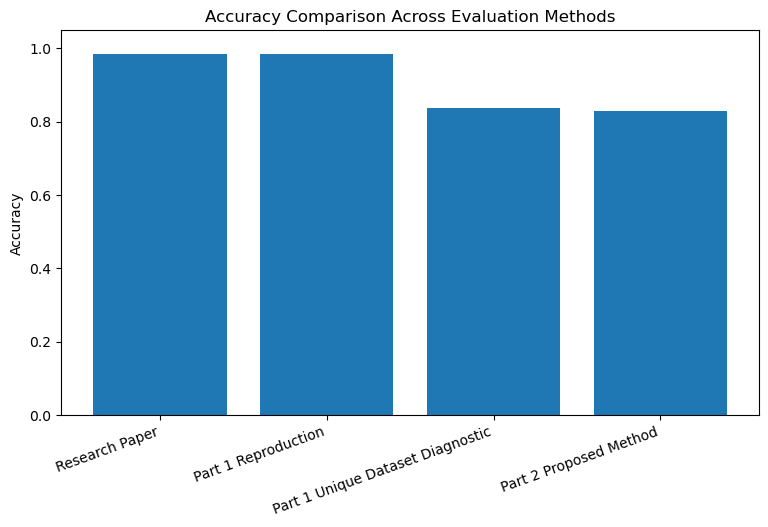

In [97]:
plt.figure(figsize=(9, 5))

plt.bar(
    final_part2_comparison["Method"],
    final_part2_comparison["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Accuracy Comparison Across Evaluation Methods")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")

plt.show()

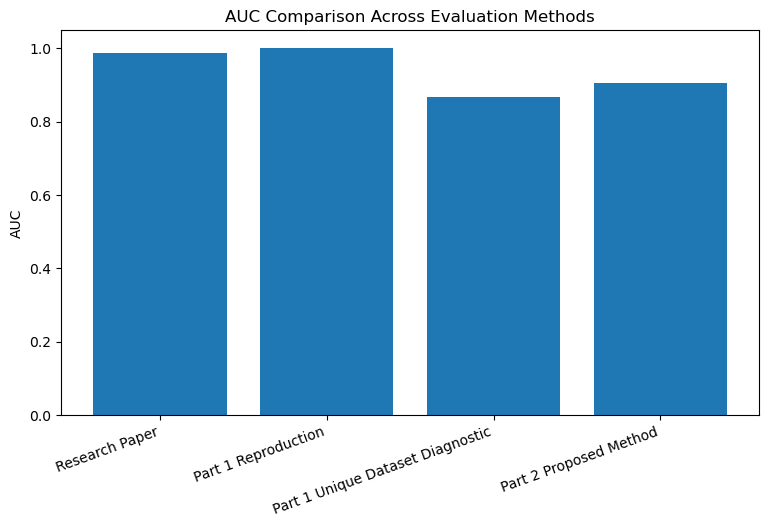

In [98]:
plt.figure(figsize=(9, 5))

plt.bar(
    final_part2_comparison["Method"],
    final_part2_comparison["AUC"]
)

plt.ylabel("AUC")
plt.title("AUC Comparison Across Evaluation Methods")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")

plt.show()

## Acknowledgement

I acknowledge that I use ChatGPT during this task to support brainstorming, planning the structure of the experiments, identifying appropriate Python libraries and functions, and assisting with the creation of graphs, tables, and charts. I also used ChatGPT to help review explanations and improve the clarity of my writing. All suggestions generated are reviewed and adapted before included in the final submission. I confirm that I understand the methods, code, experimental results, and analysis presented in this work, and that the final submission represents my own understanding and decisions.

## References
Bhagat, M., Sharma, A., & Agarwal, P. (2024). An efficient stacking-based ensemble technique for early heart attack prediction. Multimedia Tools and Applications, 84(30), 36351–36375. https://doi.org/10.1007/s11042-024-19293-7

GeeksforGeeks. (2017, March 3). Naive Bayes classifiers. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/naive-bayes-classifiers/

GeeksforGeeks. (2019, May 20). Stacking in machine learning. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/stacking-in-machine-learning/

GeeksforGeeks. (2020, August 6). Stratified K fold cross validation. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/stratified-k-fold-cross-validation/

GeeksforGeeks. (2021, September 18). XGBoost. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/xgboost/

scikit-learn. (2014). LogisticRegression. Scikit-Learn.Org. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

scikit-learn. (2019). 1.9. Naive bayes — Scikit-learn 0.21.3 documentation. Scikit-Learn.Org. https://scikit-learn.org/stable/modules/naive_bayes.html

scikit-learn. (2019a). Sklearn.Ensemble.StackingClassifier — Scikit-learn 0.23.2 documentation. Scikit-Learn.Org. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html

scikit-learn. (2019b). Sklearn.Neighbors.KNeighborsClassifier — Scikit-learn 0.22.1 documentation. Scikit-Learn.Org. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

scikit-learn. (2019c). Sklearn.Tree.DecisionTreeClassifier — Scikit-learn 0.22.1 documentation. Scikit-Learn.Org. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

scikit-learn. (2024). Sklearn.Model_selection.RepeatedStratifiedKFold. Scikit-Learn. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html

scikit-learn. (2025). Sklearn.Ensemble.RandomForestClassifier — Scikit-learn 0.20.3 documentation. Scikit-Learn.Org. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html